<div style="text-align: center;"">
  <img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcRxFd97cysduy-FEFTr_r8HhFuiFaGTdJ5bMQ&s" width="500">
</div>

<h1 align="center">✈️ Airline Passengers Satisfaction Dataset</h1>

<p align="center">
  <strong>Exploratory Data Analysis (EDA) & Insights</strong><br>
  <em>Understanding customer behavior • Service experience • Satisfaction patterns</em>
</p>

---

## 📌 Project Overview

This notebook performs an in-depth analysis of the **Airline Passengers Satisfaction Dataset**, focusing on identifying the factors that impact customer satisfaction.  
We explore patterns in demographics, flight behavior, service ratings, and delays.

---

## 🎯 Objectives

- Clean and preprocess the dataset  
- Explore key satisfaction trends  
- Visualize behavioral and service-rating patterns  
- Identify features that most influence satisfaction  
- Build a foundation for predictive modeling  

---

## 📂 Dataset Snapshot

The dataset includes:
- Demographics: `Age`, `Gender`, `Customer Type`, `Type of Travel`  
- Flight details: `Class`, `Flight Distance`, `Departure/Arrival Delays`  
- Service ratings: `WiFi`, `Food`, `Comfort`, `Cleanliness`, `Service Quality`  
- Target variable: `Satisfaction` (Satisfied / Dissatisfied)

---



## 🛠️ Tools & Libraries

We will use:

- **pandas** for data manipulation  
- **numpy** for numerical operations  
- **matplotlib** & **seaborn** for visualization  
- **scikit-learn** for preprocessing & modeling

---

## 🧭 Notebook Structure

1. **Data Loading**
2. **Data Cleaning**
3. **Exploratory Data Analysis (EDA)**
4. **Feature Engineering**
5. **Modeling (optional)**
6. **Insights & Conclusion**
 

# Importing Libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data Cleaning

In [2]:
data = pd.read_csv("Airline Passengers Satisfaction Dataset.xlsx - Sheet1.csv")
data

,Passenger ID,First Name,Last Name,Gender,Age,Nationality,Airport Name,Airport Country Code,Country Name,Airport Continent,...,On-board Service,Seat Comfort,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling,Satisfaction
0,ABVWIg,Edithe,Leggis,Female,62,Japan,Coldfoot Airport,US,United States,NAM,...,3,5,2,5,5,5,3,5,5,Neutral or Dissatisfied
1,jkXXAX,Elwood,Catt,Male,62,Nicaragua,Kugluktuk Airport,CA,Canada,NAM,...,5,4,5,5,3,5,2,5,5,Satisfied
2,CdUz2g,Darby,Felgate,Male,67,Russia,Grenoble-Isère Airport,FR,France,EU,...,3,5,3,5,5,3,4,3,3,Satisfied
3,BRS38V,Dominica,Pyle,Female,71,China,Ottawa / Gatineau Airport,CA,Canada,NAM,...,5,5,5,4,4,5,2,5,5,Satisfied
4,9kvTLo,Bay,Pencost,Male,21,China,Gillespie Field,US,United States,NAM,...,3,4,4,5,4,3,3,3,3,Satisfied
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98614,hnGQ62,Gareth,Mugford,Male,85,China,Hasvik Airport,NO,Norway,EU,...,5,4,5,3,3,5,4,5,5,Satisfied
98615,2omEzh,Kasey,Benedict,Female,19,Russia,Ampampamena Airport,MG,Madagascar,AF,...,4,5,4,3,3,4,5,4,4,Satisfied
98616,VUPiVG,Darrin,Lucken,Male,65,Indonesia,Albacete-Los Llanos Airport,ES,Spain,EU,...,4,4,4,3,5,4,3,4,4,Satisfied
98617,E47NtS,Gayle,Lievesley,Female,34,China,Gagnoa Airport,CI,Côte d'Ivoire,AF,...,4,1,5,1,1,4,2,1,4,Neutral or Dissatisfied


In [3]:
data.dropna(inplace = True)

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 98313 entries, 0 to 98618
Data columns (total 36 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Passenger ID                            98313 non-null  object 
 1   First Name                              98313 non-null  object 
 2   Last Name                               98313 non-null  object 
 3   Gender                                  98313 non-null  object 
 4   Age                                     98313 non-null  int64  
 5   Nationality                             98313 non-null  object 
 6   Airport Name                            98313 non-null  object 
 7   Airport Country Code                    98313 non-null  object 
 8   Country Name                            98313 non-null  object 
 9   Airport Continent                       98313 non-null  object 
 10  Continents                              98313 non-null  object 

In [5]:
data.isnull().sum()/len(data)*100

Passenger ID                              0.0
First Name                                0.0
Last Name                                 0.0
Gender                                    0.0
Age                                       0.0
Nationality                               0.0
Airport Name                              0.0
Airport Country Code                      0.0
Country Name                              0.0
Airport Continent                         0.0
Continents                                0.0
Departure Date                            0.0
Arrival Airport                           0.0
Pilot Name                                0.0
Flight Status                             0.0
Customer Type                             0.0
Type of Travel                            0.0
Class                                     0.0
Flight Distance                           0.0
Departure Delay                           0.0
Arrival Delay                             0.0
Departure and Arrival Time Conveni

In [6]:
data.columns

Index(['Passenger ID', 'First Name', 'Last Name', 'Gender', 'Age',
       'Nationality', 'Airport Name', 'Airport Country Code', 'Country Name',
       'Airport Continent', 'Continents', 'Departure Date', 'Arrival Airport',
       'Pilot Name', 'Flight Status', 'Customer Type', 'Type of Travel',
       'Class', 'Flight Distance', 'Departure Delay', 'Arrival Delay',
       'Departure and Arrival Time Convenience', 'Ease of Online Booking',
       'Check-in Service', 'Online Boarding', 'Gate Location',
       'On-board Service', 'Seat Comfort', 'Leg Room Service', 'Cleanliness',
       'Food and Drink', 'In-flight Service', 'In-flight Wifi Service',
       'In-flight Entertainment', 'Baggage Handling', 'Satisfaction'],
      dtype='object')

In [7]:
# Creaing the pre-flight service rate column.
# It will based on the values in the columns [Ease of Online Booking, Check-in Service, Online Boarding, Gate Location]

data["Pre-flight Service Rate"] =  data["Ease of Online Booking"] + data["Check-in Service"] + data["Gate Location"] + data["Online Boarding"]

In [8]:
# Creating a column for pre-flight service.
data["Pre-flight Service"] = np.where(
    data["Pre-flight Service Rate"] < 5, "Poor",
    np.where(
        data["Pre-flight Service Rate"] < 10, "Natural",
        np.where(
            data["Pre-flight Service Rate"] < 15, "Good",
            "Excellent"
        )
    )
)
data["Pre-flight Service"]

0             Good
1             Good
2        Excellent
3             Good
4             Good
           ...    
98614    Excellent
98615    Excellent
98616         Good
98617      Natural
98618         Good
Name: Pre-flight Service, Length: 98313, dtype: object

In [9]:
# Creating the in-flight service rate column.
"""
 It will be based on the values in the columns ['On-board Service', 'Seat Comfort', 'Leg Room Service', 'Cleanliness',
       'Food and Drink', 'In-flight Service', 'In-flight Wifi Service','In-flight Entertainment']
"""
data["In-flight Service Rate"] = data["On-board Service"] + data["Seat Comfort"] + data["Leg Room Service"] + data["Cleanliness"] +data["Food and Drink"] + data["In-flight Service"] + data["In-flight Wifi Service"] + data["In-flight Entertainment"]

In [10]:
# Creating a column for in-flight service.
data["In-flight Service"] = np.where(
    data["In-flight Service Rate"] < 10, "Poor",
    np.where(
        data["In-flight Service Rate"] < 20, "Natural",
        np.where(
            data["In-flight Service Rate"] < 30, "Good",
            "Excellent"
        )
    )
)
data["In-flight Service"]

0        Excellent
1        Excellent
2        Excellent
3        Excellent
4             Good
           ...    
98614    Excellent
98615    Excellent
98616    Excellent
98617      Natural
98618         Good
Name: In-flight Service, Length: 98313, dtype: object

In [11]:
# Creaing the post-flight service rate column.
# It will based on the values in the columns ['Baggage Handling'], so, we can leave it the same.

# Then, we will compute the total service rate for the company.

data["Total Service"] = data["Pre-flight Service Rate"] + data["In-flight Service Rate"] + data["Baggage Handling"]

In [12]:
# We can make a column for Age Group


data["Age Group"] = np.where(
    data["Age"] < 18, "Under 18",
    np.where(
        (data["Age"] >= 18) & (data["Age"] <= 25), "18-25",
        np.where(
            (data["Age"] >= 26) & (data["Age"] <= 35), "26-35",
            np.where(
                (data["Age"] >= 36) & (data["Age"] <= 45), "36-45", 
            np.where(
                (data["Age"] >= 46) & (data["Age"] <= 55), "46-55",
                "+55"
            )
            
        )
    )
    )

)
data["Age Group"]

0             +55
1             +55
2             +55
3             +55
4           18-25
           ...   
98614         +55
98615       18-25
98616         +55
98617       26-35
98618    Under 18
Name: Age Group, Length: 98313, dtype: object

In [13]:
data

,Passenger ID,First Name,Last Name,Gender,Age,Nationality,Airport Name,Airport Country Code,Country Name,Airport Continent,...,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling,Satisfaction,Pre-flight Service Rate,Pre-flight Service,In-flight Service Rate,Total Service,Age Group
0,ABVWIg,Edithe,Leggis,Female,62,Japan,Coldfoot Airport,US,United States,NAM,...,Excellent,3,5,5,Neutral or Dissatisfied,13,Good,33,51,+55
1,jkXXAX,Elwood,Catt,Male,62,Nicaragua,Kugluktuk Airport,CA,Canada,NAM,...,Excellent,2,5,5,Satisfied,12,Good,34,51,+55
2,CdUz2g,Darby,Felgate,Male,67,Russia,Grenoble-Isère Airport,FR,France,EU,...,Excellent,4,3,3,Satisfied,17,Excellent,31,51,+55
3,BRS38V,Dominica,Pyle,Female,71,China,Ottawa / Gatineau Airport,CA,Canada,NAM,...,Excellent,2,5,5,Satisfied,11,Good,35,51,+55
4,9kvTLo,Bay,Pencost,Male,21,China,Gillespie Field,US,United States,NAM,...,Good,3,3,3,Satisfied,14,Good,29,46,18-25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98614,hnGQ62,Gareth,Mugford,Male,85,China,Hasvik Airport,NO,Norway,EU,...,Excellent,4,5,5,Satisfied,15,Excellent,34,54,+55
98615,2omEzh,Kasey,Benedict,Female,19,Russia,Ampampamena Airport,MG,Madagascar,AF,...,Excellent,5,4,4,Satisfied,18,Excellent,32,54,18-25
98616,VUPiVG,Darrin,Lucken,Male,65,Indonesia,Albacete-Los Llanos Airport,ES,Spain,EU,...,Excellent,3,4,4,Satisfied,14,Good,31,49,+55
98617,E47NtS,Gayle,Lievesley,Female,34,China,Gagnoa Airport,CI,Côte d'Ivoire,AF,...,Natural,2,1,4,Neutral or Dissatisfied,9,Natural,19,32,26-35


In [14]:
data['Gender'].value_counts().get('Male', 0)/len(data)*100

50.29446766958592

In [15]:
data['Type of Travel'].value_counts()/len(data)*100

Type of Travel
Business    69.105815
Personal    30.894185
Name: count, dtype: float64

In [16]:
data['Class'].value_counts()/len(data)*100

Class
Economy         46.416039
Business        45.879996
Economy Plus     7.703966
Name: count, dtype: float64

In [17]:
data['Flight Status'].value_counts()/len(data)*100

Flight Status
Cancelled    33.406569
On Time      33.301801
Delayed      33.291630
Name: count, dtype: float64

<Axes: ylabel='count'>

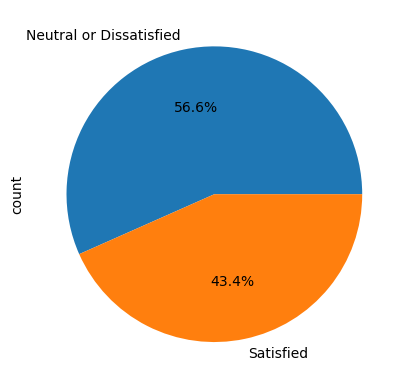

In [18]:
data['Satisfaction'].value_counts().plot(kind='pie', autopct='%1.1f%%')

In [19]:
data.loc[(data["Satisfaction"] == "Neutral or Dissatisfied") & (data["Total Service"] < 25), "Satisfaction"] = "Dissatisfied"
data.loc[(data["Satisfaction"] == "Neutral or Dissatisfied") & (data["Total Service"] >= 25) & (data["Total Service"] <= 55), "Satisfaction"] = "Neutral"


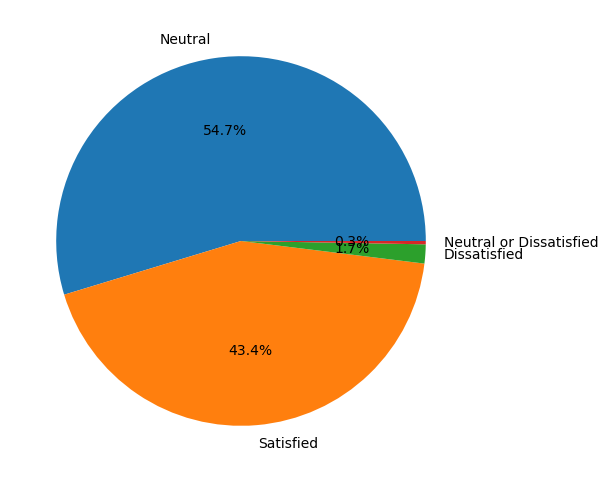

In [20]:
counts = data["Satisfaction"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(counts, labels=counts.index, autopct='%1.1f%%')
plt.show()
